
# Linear Regression

At a fundamental level, neural network architectures are built upon the same core ideas as linear and logistic regression. For this reason, we begin the course with a review of these topics, supported by simple worked examples.

These notes provide a relatively detailed introduction to Linear Regression and it draws on several standard machine learning courses. While you may already be familiar with parts of this material, revisiting it here serves an important purpose.

Much of what we cover in linear regression—loss functions, model training, optimization, and regularization—forms the conceptual foundation of deep learning. Neural networks can be viewed as a structured composition of many linear models combined with nonlinear transformations. Understanding how these ideas work in their simplest form will make it much easier to understand deep learning models later in the course.


## Introduction

We begin by defining a few key concepts that will be used throughout the course and illustrating them with simple examples.

### Definition: Target

The Target is the output variable that our model aims to predict.
In statistics, this is commonly referred to as the `dependent variable`.

- The target is typically denoted by the symbol $Y$.
- In linear regression, the target variable is a continuous, real-valued quantity. Linear regression is not intended to be used for categorical or binary prediction tasks.

When implementing models in code, the target may be assigned a more descriptive variable name, but conceptually it always represents the quantity we are trying to predict.

### Example

In a typical linear regression setting, we might be interested in modeling the relationship between age and height.

In this case:
- Age is the input (feature)
- Height is the target (dependent variable)

Assuming height is measured in meters, we can represent a collection of height measurements as a vector using NumPy. A NumPy array behaves like a mathematical vector and is the standard data structure used for numerical computation in machine learning.

Note that a NumPy array is typically initialized from a native Python list.

In [1]:
import numpy as np
Y = np.array([60,90,100.5,130,128,140,160,140,165,162,155])
print("Our height vector is ", Y)

Our height vector is  [ 60.   90.  100.5 130.  128.  140.  160.  140.  165.  162.  155. ]


### Definition: Predictor Features
Predictor features are the input features to our model and are referred to as independent variables in the statistics literature. The predictor features are usually denoted with the symbol $X$. A single $X$ is used in the case where there is only one predictor feature while $X$ is indexed ($X_{1}$) when there is more than one predictor feature.

In our height modeling example, we might start with a single predictor feature: `age`.

In [2]:
X = np.array([1,3,4,7,10,11,14,13.5,16,18,22])
print("Our age vector is ", X)

Our age vector is  [ 1.   3.   4.   7.  10.  11.  14.  13.5 16.  18.  22. ]


In most cases, the independent variables (features) are real-valued, though the requirements are not as strict as for the dependent variable. Binary or categorical features are possible, but for most of our examples, we will focus on real-valued inputs.

By convention, the target feature is referred to as the Target, while the predictor features are simply called Features.

We can visualize our Height and Age data as follows:

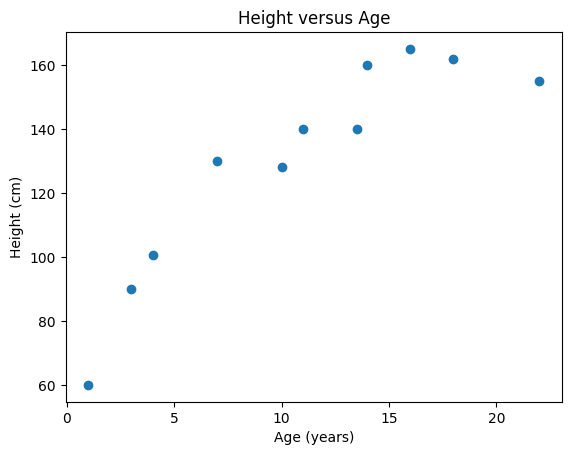

In [3]:
%matplotlib inline

import matplotlib.pyplot as plt

plt.plot(X,Y, "o")
plt.title('Height versus Age')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')
plt.show()

Examining our data we can clearly see a relationship between Age and Height but how do we model the relationship between the two variables? We could start with correlation:

In [4]:
from scipy.stats import pearsonr
r,p = pearsonr(X,Y)
print('r value is ',r)
print('p value is',p)

r value is  0.9028496585155188
p value is 0.00014105270724641005


### Recap: Pearson Correlation (Linear Relationship)

The function `pearsonr(X, Y)` measures the **linear correlation** between two variables `X` and `Y`.

It returns **two values**:

- **r**: the correlation coefficient  
- **p**: the p-value (statistical significance)

---

#### Correlation Coefficient (`r`)

- **Range:** −1 to +1

**Interpretation:**

- `r ≈ +1` → strong positive linear relationship  
  (as `X` increases, `Y` increases)

- `r ≈ −1` → strong negative linear relationship  
  (as `X` increases, `Y` decreases)

- `r ≈ 0` → little or no linear relationship

**Example:**

- `r = 0.92` → very strong positive linear relationship

---

#### p-value (Significance Test)

The p-value tests the hypothesis:

> *“There is no linear relationship between X and Y.”*

**Interpretation:**

- Small `p` (e.g. `< 0.05`) → correlation is **statistically significant**
- Large `p` → observed correlation could be due to **random chance**


The correlation confirms that there is a strong positive relationship between the two variables. Now, let’s say we want to estimate the most likely value for Height given an Age of 9. We can do this intuitively by looking at our plot and identifying the value on the Y-axis that corresponds to 9 on the X-axis.

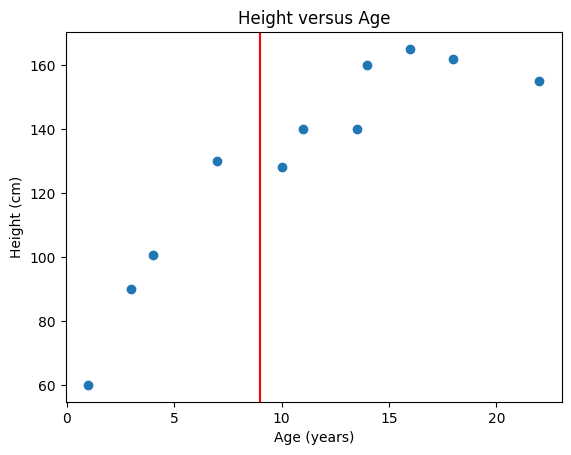

In [5]:
plt.axvline(9, color='red')
plt.plot(X,Y, "o")
plt.title('Height versus Age')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')
plt.show()

Rather than estimating manually, linear regression provides a way to fit a function to our data, allowing us to predict a likely value for the Target based on a given set of input features.


### Definition: Linear Regression
Linear Regression is a way to model the relationship between a Target and Features using a parameterized function.

The simplest function we can fit in our example is a straight line:

\begin{equation}
 Y = mX + c
\end{equation}

where $m$ is the slope of the line, and $c$ defines the line's offset from the origin.

For our toy example, we might eyeball the data and guess that a reasonable fit is:

\begin{equation}
 Y = 4X + 80
\end{equation}

It’s common to write the equation with the intercept first:

\begin{equation}
 Y = 80 + 4X
\end{equation}

We can then plot this line against our data to visualize how well it fits.

Additional Notes:
- The **slope** controls the steepness of the line, while the **intercept** determines its vertical position by specifying the value of `y` when `x = 0`.

- The **slope** controls the *tilt* of the line. It determines how much `y` changes when `x` increases by 1:
  - Large `|m|` → steep line
  - `m > 0` → line goes up as `x` increases
  - `m < 0` → line goes down as `x` increases

- The **intercept** shifts the line **up or down along the y-axis**:
  - `b` is the value of `y` when `x = 0`
  - Increasing `b` lifts the entire line upward
  - Decreasing `b` pushes the entire line downward
  - The slope remains unchanged



[ 80  84  88  92  96 100 104 108 112 116 120 124 128 132 136 140 144 148
 152 156 160 164 168 172 176]


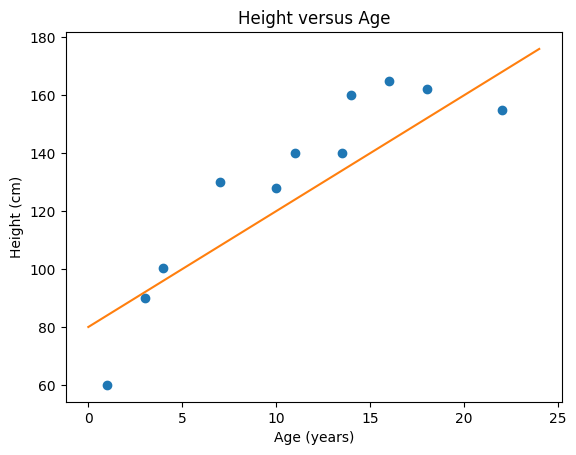

In [6]:
plt.plot(X,Y, "o")
plt.title('Height versus Age')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')
x2 = np.array([i for i in range(25)])
y2 = 80 + 4*x2
print(y2)
plt.plot(x2,y2)
plt.show()

Alternatively we might think that the linear function $Y= 60 + 6X$ might give a better fit.

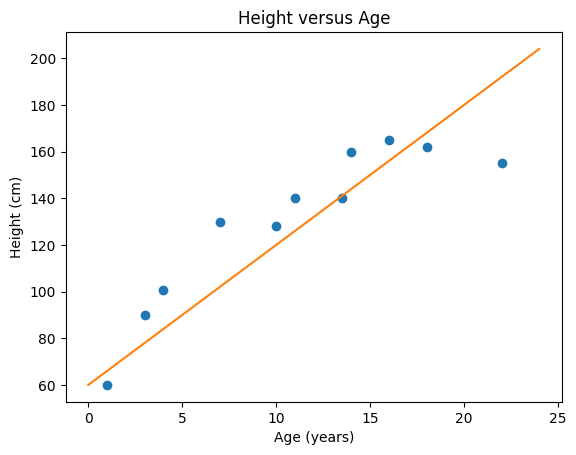

In [7]:
plt.plot(X,Y, "o")
plt.title('Height versus Age')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')
x2 = np.array([i for i in range(25)])
y2 = 60 + 6*x2
plt.plot(x2,y2)
plt.show()

We might even think that a polynomial function such as
\begin{equation}
Y = 50 + 15X - 0.68 X^{2} + 0.011 X^{3}
\end{equation}

would provide a better fit.

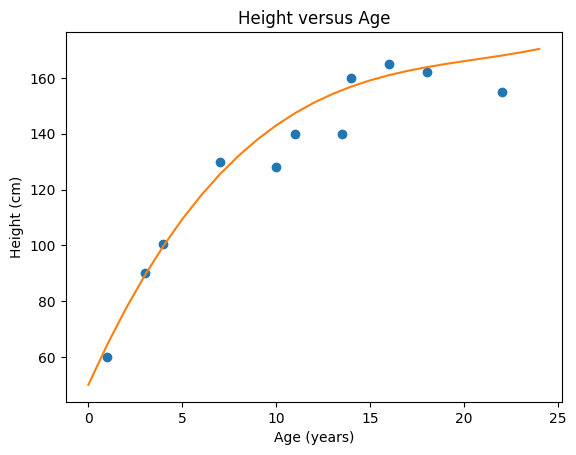

In [8]:
plt.plot(X,Y, "o")
plt.title('Height versus Age')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')
x2 = np.array([i for i in range(25)])
y2 = 50 + 15*x2 - 0.68*(x2**2)  + 0.011*(x2**3)
plt.plot(x2,y2)
plt.show()

Clearly, a polynomial could fit the data better, but for now, we will focus on purely linear functions with no higher-order terms.

## Hypothesis Function

In linear regression, we assume that the function which best fits the data is a linear function of `x`:

\begin{equation}
h_{\theta}(x) = \theta_{0} + \theta_{1}x
\end{equation}

In the literature, this is called the **hypothesis function**, because it is the function we are testing or evaluating. The hypothesis function is also often referred to as the function or the model. In these notes, we will simply refer to it as our **model**.

The $\theta$ values are the **parameters** of the model. In the examples above, we manually adjusted the parameters to get a reasonable fit. In linear regression, we automate this by finding the parameters that minimize a cost function.

## Cost Functions

**Definition** The cost function, $J$, is a function which gives us a numeric estimate of the error between the predictions of our model and the data values.

**Formal Definition**

\begin{equation}
J(\theta_{0},\theta_{1}) = \frac{1}{2m}     \sum_{i=0}^{m} ( h_{\theta}(x^{(i)}) - y^{(i)})^{2}
\end{equation}

where
 * $\theta_{0}$ and $\theta_{1}$ are the parameters of our model
 * $m$ is the number of training examples
 * $y^{i}$ is the ith target value
 * $x^{i}$ is the ith feature vector, and
 * $h_{\theta}$ is our model (hypothesis function)

**Intuition**

The cost function measures the difference between the ground truth values and our model’s predictions. Instead of summing the raw differences, we sum the squared differences. This has two benefits:

1. Positive and negative errors won’t cancel each other out.
2. Larger errors are penalized more heavily, while small errors are penalized lightly. This encourages the model to focus on correcting the biggest mistakes first.


The factor $\frac{1}{2m}$ is not technically needed for the cost function, but it simplifies the derivative of the cost function later when we optimize the parameters numerically.

This cost function is also called the **Sum of Squared Errors (SSE)**.


**Example**
We can use this function to directly calculate the cost associated with our linear equation for the Height–Age data, giving us a numeric measure of how well our model fits the data.

In [9]:
def hyp(theta0,theta1,x):
    """This is our actual model function that combines parameters with an input feature (x)
        to return a value (which would be y)"""
    return theta0 + theta1*x

def J(theta0,theta1,x,y,h):
    """This is the function that calculates our cost for a hypothesised function and a set
        of training data. """
    s = 0
    m = len(x)
    for i in range(0,m):
        delta = h(theta0,theta1,x[i]) - y[i]
        delta = delta**2
        s+= delta
    return s / (2*m)

print("Cost for y = 80 + 4*x : " + str(J(80,4,X,Y,hyp)))

print("Cost for y = 60 + 6*x : " + str(J(60,6,X,Y,hyp)))

Cost for y = 80 + 4*x : 123.92045454545455
Cost for y = 60 + 6*x : 147.23863636363637


### Minimizing Cost Functions

**Intuition**
Our goal is to choose values for $\theta_{0}$ and $\theta_{1}$ that minimizes the cost function $J$.

For a linear model with two parameters, the cost function forms a surface in 3D space. We can produce a visualization of this cost surface by scanning over a range of values for $\theta_{0}$ and $\theta_{1}$ as follows:

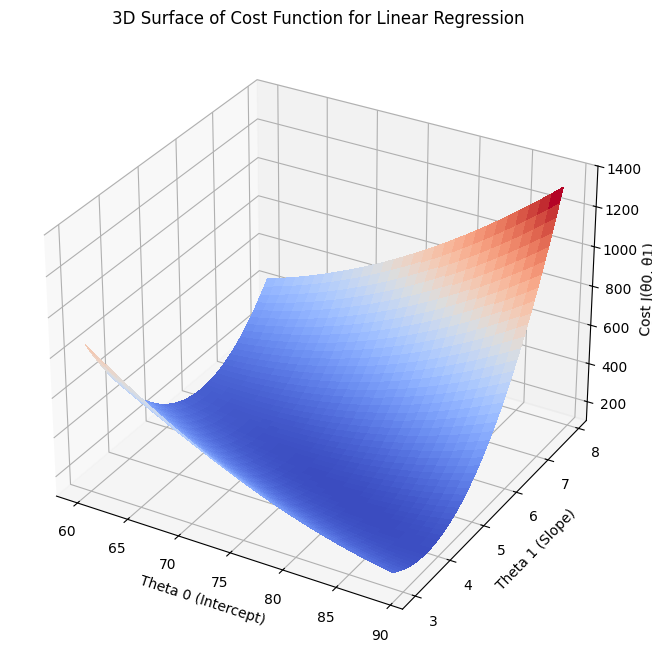

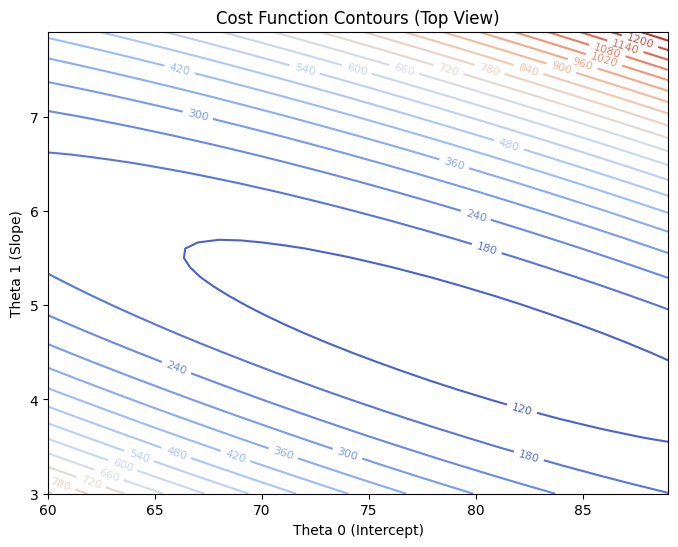

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormap
import numpy as np

# -------------------------------------------------------------
# Cost Function Visualization
# -------------------------------------------------------------
# This code does NOT train a model.
# It visualizes the cost function J(θ0, θ1) for a single-feature linear regression.
# Think of it as drawing the "landscape" that gradient descent would walk on.
# -------------------------------------------------------------

# Sample dataset (single feature)
X_single_feature = np.array([1, 3, 4, 7, 10, 11, 14, 13.5, 16, 18, 22])
Y_single_feature = np.array([60, 90, 100.5, 130, 128, 140, 160, 140, 165, 162, 155])

# Define ranges for θ0 (intercept) and θ1 (slope)
theta0_range = range(60, 90)             # θ0 from 60 to 89
theta1_range = np.arange(3, 8, 0.1)      # θ1 from 3.0 to 7.9

# Create a meshgrid of all (θ0, θ1) combinations
theta0s, theta1s = np.meshgrid(theta0_range, theta1_range)

# Compute the cost function for all combinations
costs = J(theta0s, theta1s, X_single_feature, Y_single_feature, hyp)

# -------------------------------------------------------------
# 3D Surface Plot of the Cost Function
# -------------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

# Plot the surface
surf = ax.plot_surface(
    theta0s, theta1s, costs,
    rstride=1, cstride=1,
    cmap=cm.coolwarm,
    linewidth=0,
    antialiased=False
)

# Set z-axis limits for better visualization
ax.set_zlim(100, 1400)

# Add labels and title
ax.set_xlabel("Theta 0 (Intercept)")
ax.set_ylabel("Theta 1 (Slope)")
ax.set_zlabel("Cost J(θ0, θ1)")
ax.set_title("3D Surface of Cost Function for Linear Regression")

# Display the plot
plt.show()

# -------------------------------------------------------------
# 2D Contour Plot of the Cost Function
# -------------------------------------------------------------
plt.figure(figsize=(8, 6))

CS = plt.contour(theta0s, theta1s, costs, levels=20, cmap=cm.coolwarm)
plt.clabel(CS, inline=1, fontsize=8)

plt.xlabel("Theta 0 (Intercept)")
plt.ylabel("Theta 1 (Slope)")
plt.title("Cost Function Contours (Top View)")

plt.show()


So lets read this graph:
- Each point on this surface corresponds to one specific linear model: hθ​(x)=$θ_{0}$​+$θ_{1}​x$
- X axis: $θ_{0}$ (intercept)
- Y axis: $θ_{1}$ (slope)
- Z axis: J($θ_{0}$, $θ_{1}$) (cost)

The bowl shape
- This surface should look like a smooth bowl (a convex function).
- That tells you something very important:
    - There is exactly one global minimum
    - No local minima to trap gradient descent

The bottom of the bowl represents the best-fitting line for your data.

If you dropped a marble anywhere on this surface and let it roll downhill it would end up at this minimum.

Above, we performed a manual (brute-force) search over $\theta$ values.  
This is essentially a **grid search over parameter space**.

This simple model has only **two parameters**, but real-world models can have **thousands or even millions of parameters**. Exhaustively evaluating all possible parameter combinations quickly becomes **computationally infeasible**.

What We Do Instead: Optimization Algorithms

Rather than checking every possible value of $\theta$, we use **optimization algorithms** that let the mathematics guide us *downhill* toward the minimum of the cost function.

The most commonly used optimization algorithm for this purpose is **Gradient Descent**.

**Key Idea:** To find the best fit for our linear equation we want to minimize the cost function to locate:

\begin{equation}
min_{\theta_{0},\theta_{1}} J(\theta_{0},\theta_{1})
\end{equation}

We will use gradient descent algorithm to perform that.

**Intuition**

We start with an initial (often random) choice of $\theta_{0}$ and $\theta_{1}$ and iteratively adjust these parameters to reduce the cost function. Instead of making random adjustments, we compute the derivatives of the cost function, which indicate the direction of steepest increase, and update the parameters in the opposite direction to achieve the fastest decrease in cost.

### Gradient Descent Algorithm

The core update rule of the gradient descent algorithm is:

Repeat Until Convergence {
\begin{equation}
\theta_{j} = \theta_{j} - \alpha \frac{\partial J(\theta_{0},\theta_{1})}{\partial \theta_{j}} \;\; for \; j=0:1
\end{equation}
}

where $\alpha$ = learning rate. The learning rate controls the size of each update step:
- Large values of $\alpha$ result in larger steps, which may speed up learning but risk overshooting the minimum
- Small values of $\alpha$ lead to smaller steps, resulting in slower but more stable convergence

**Simultaneous Parameter Updates**

Although the update rule is written in terms of individual parameters, both
$\theta_{0}$ and then $\theta_{1}$ must be updated simultaneously at each iteration.

If one parameter were updated before the other, the second update would incorrectly depend on a partially updated model. To avoid this, the gradients are first computed using the current parameter values, and then both parameters are updated together. In practice, this is implemented using temporary variables.

**Role of the Partial Derivatives**

The gradient descent algorithm relies on computing the partial derivatives of the cost function with respect to each parameter. These derivatives measure how sensitive the cost function is to small changes in each parameter.

Each partial derivative indicates the direction and rate at which the cost increases most rapidly with respect to that parameter. By subtracting a fraction of this derivative, gradient descent updates the parameters in the direction that most rapidly decreases the cost.

The explicit expressions for these partial derivatives are derived in the following section.

**Derivation**

\begin{equation}
\frac{\partial}{\partial \theta_{j}}J(\theta_{0},\theta_{1})
\end{equation}

Substituting in the equation for $J(\theta_{0},\theta_{1})$ we get

\begin{equation}
\frac{\partial}{\partial \theta_{j}}   \frac{1}{2m}     \sum_{i=0}^{m} ( (h_{\theta}(x^{(i)}) - y^{(i)})^{2} )
\end{equation}

Substituting the definition $h_{\theta}(x^{(i)}) = \theta_{0} + \theta_{1}x^{i}$ we get:

\begin{equation}
\frac{\partial}{\partial \theta_{j}}   \frac{1}{2m}     \sum_{i=0}^{m} ( (\theta_{0} + \theta_{1}x^{i} - y^{(i)})^{2} )
\end{equation}

We now perform the partial derivations for each of the parameters:

\begin{equation}
j=0 \; : \; \frac{\partial}{\partial \theta_{0}}J(\theta_{0},\theta_{1}) = \frac{1}{m} \sum_{i=0}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})
\end{equation}

\begin{equation}
j=1 \; : \; \frac{\partial}{\partial \theta_{1}}J(\theta_{0},\theta_{1}) = \frac{1}{m} \sum_{i=0}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}).x^{(i)}
\end{equation}

We can then substitute these partial derivative formula back into the definition of gradient descent algorithm:

Repeat Until Convergence {

  > perform simultaneously {
\begin{equation}
\theta_{0} = \theta_{0} - \alpha \frac{1}{m} \sum_{i=0}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})
\end{equation}

> \begin{equation}
\theta_{1} = \theta_{1} - \alpha \frac{1}{m} \sum_{i=0}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}).x^{i}
\end{equation}
  }

}

Based on the above we can provide an implementation of the Gradient Descent algorithm as shown below.

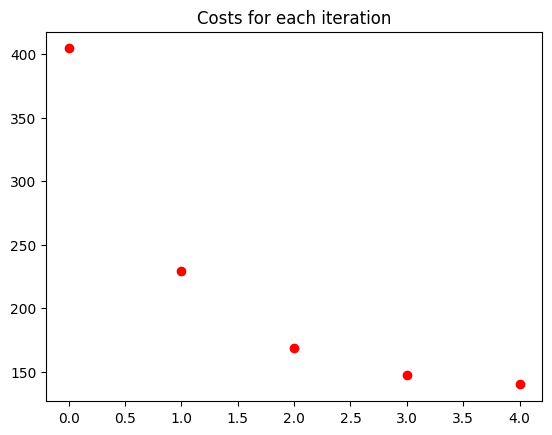

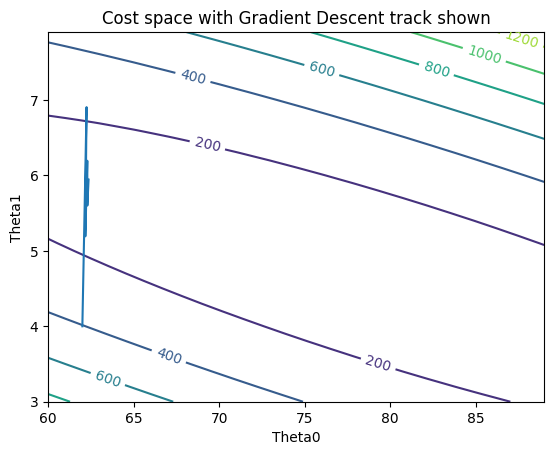

Learned parameters:
theta_0 = 62.36199802607035
theta_1 = 5.944761620188047


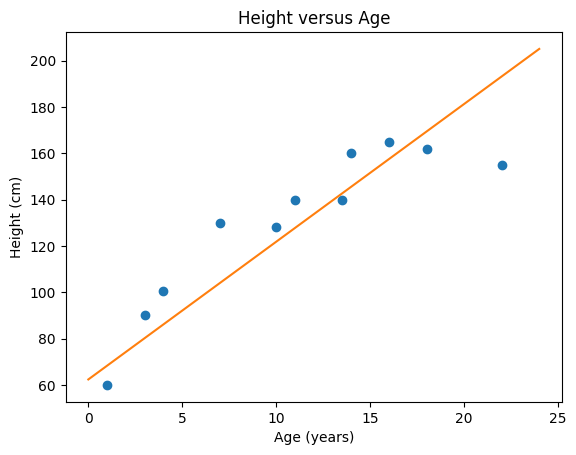

In [11]:
def gd(t0_in,t1_in,min_delta_in,a_in,X_in,Y_in,hyp_in):
    """Implementation of a simple gradient descent algorithm. Inputs are:
        t0_in --- initial guess at parameter t0
        t1_in --- initial guess at parameter t1
        min_delta_in --- a minimum change. If in an iteraction our change is less than this, we are finished.
        a_in --- learning rate
        X_in --- vector of input values
        Y_in --- vector of output values
        hyp_in --- our hypotheis function
        """
    m = len(X_in)
    c = []
    t0s = []
    t1s = []

    t0 = t0_in
    t1 = t1_in
    t0s.append(t0_in)
    t1s.append(t1_in)

    # note - there is no do while construct in python.
    while True:
        # calculate the cost based on the current parameters
        c.append(J(t0,t1,X_in,Y_in,hyp_in))

        temp0 = t0
        temp1 = t1
        s = 0
        # iterate over each of the inputs and calculate elements for t_0 update
        for i in range(0,m):
            s+=  (hyp_in(temp0,temp1,X_in[i]) - Y_in[i])
        t0 = temp0 - a_in * (1/m) * s

        s = 0
        # iterate over each of the inputs and calculate elements for t_1 update
        for i in range(0,m):
            s+=  (hyp_in(temp0,temp1,X_in[i]) - Y_in[i]) * X_in[i]
        t1 = temp1 - a_in * (1/m) * s

        t0s.append(t0)
        t1s.append(t1)

        # check if our parameters are still seeing large updates -- if not, break
        if( (abs(temp0 - t0) < min_delta_in) and (abs(temp1 - t1) < min_delta_in) ):
            break
    return t0s, t1s, c

t0s, t1s, c = gd(62,4,0.5,0.01,X,Y,hyp)

plt.plot(c, 'ro')
plt.title('Costs for each iteration')
plt.show()

plt.figure()
CS = plt.contour(theta0s, theta1s, costs)
plt.plot(t0s,t1s)
plt.xlabel('Theta0')
plt.ylabel('Theta1')
plt.clabel(CS, inline=1, fontsize=10)
plt.title('Cost space with Gradient Descent track shown')
plt.show()

print(f"Learned parameters:")
print(f"theta_0 = {t0s[-1]}")
print(f"theta_1 = {t1s[-1]}")

plt.plot(X,Y, "o")
plt.title('Height versus Age')
plt.xlabel('Age (years)')
plt.ylabel('Height (cm)')
x2 = np.array([i for i in range(25)])
y2 = t0s[-1] + t1s[-1]*x2
plt.plot(x2,y2)
plt.show()

## Normalization and Learning Rate Effects

Our result is reasonable but not ideal. We can see that while good progress was made in finding an appropriate value for $\theta_1$, very poor progress was made for $\theta_0$.

This happens because the learning rate $\alpha$ was small. Recall that the update rules are:

$$
\theta_0 := \theta_0 - \alpha \frac{1}{m} \sum_{i=0}^{m-1} \big(h_\theta(x^{(i)}) - y^{(i)}\big)
$$

$$
\theta_1 := \theta_1 - \alpha \frac{1}{m} \sum_{i=0}^{m-1} \big(h_\theta(x^{(i)}) - y^{(i)}\big) x^{(i)}
$$

- The gradient for $\theta_0$ depends only on the errors $(h_\theta(x^{(i)}) - y^{(i)})$, which are relatively small.  
- The gradient for $\theta_1$ is multiplied by $x^{(i)}$ (Age), which can be much larger, so $\theta_1$ moves more per iteration.  

With a small $\alpha$:

- $\theta_1$ moves significantly because its gradient is large.  
- $\theta_0$ barely moves because its gradient is small.  

If we had chosen a larger $\alpha$, $\theta_0$ would move faster, but $\theta_1$ could **overshoot or diverge**.

This scale difference is why **feature normalization** (scaling inputs to a similar range) is important. Normalization ensures both parameters update efficiently with the same learning rate.


## Normalization

To correct for scale-related issues, we need to ensure that each of our input features has a **similar numerical scale**. This process is referred to as **normalization**.

Normalization is necessary because **gradient descent is not scale-invariant**. If different features operate on very different scales, the cost surface becomes stretched, causing gradient descent to converge slowly or inefficiently.

---

## Common Normalization Methods

Within the machine learning community, two normalization techniques are most commonly used:

- **Feature Scaling (Min–Max Scaling)**
- **Z-Score Normalization (Standardization)**

---

### Feature Scaling (Min–Max Scaling)

**Feature scaling**, also known as **min–max scaling**, rescales the data so that all values lie in the interval $[0,1]$.

The transformation is defined as:

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

After this transformation:
- The smallest value becomes 0
- The largest value becomes 1
- All other values are linearly mapped in between

---

### Z-Score Normalization (Standardization)

**Z-score normalization**, often simply called **standardization**, rescales data so that each value represents the number of standard deviations it lies away from the mean.

The transformation is defined as:

$$
x' = \frac{x - \mu}{\sigma}
$$

where:
- $\mu$ is the mean of the feature values
- $\sigma$ is the standard deviation of the feature values

After standardization:
- The transformed data has mean 0
- The transformed data has standard deviation 1

---

## When to Use Feature Scaling

Feature scaling is a sensible choice when one or more of the following conditions apply:

- The original feature has **fixed and known bounds**  
  (e.g. pixel intensities in the range 0–255).
- The learning algorithm **requires inputs to lie within a fixed interval**,  
  such as $[0,1]$ (for example, certain neural network activation functions).

---

## Why Z-Score Normalization Is Often Preferred

In practice, **z-score normalization is more commonly used** in machine learning. The primary reason is that it naturally handles **new data points that fall outside the range of the training data**.

Unlike min–max scaling:
- Z-score normalization does **not depend on fixed minimum or maximum values**
- New test data can exceed the original data range without breaking the scaling

This makes z-score normalization more robust and better suited for real-world applications.

That said, the choice of normalization technique is **application-dependent**, and there is no single method that is always optimal.

In the examples that follow, we will use **z-score normalization**.

---

## Scaling and the Target Variable

When input features are **centered around zero** (as in z-score normalization), an additional and useful consequence appears:

- The optimal value of $\theta_0$ corresponds to the mean of the target variable (So in short: because x is 0 on average, the model prediction at that point is just $\theta_0$ which aligns with the mean of $x$, as
   - $\bar{y} = \theta_0 + \theta_1 * \bar{x}$ => where ($\bar{x}\approx 0$)
   - $\bar{y} \approx \theta_0 + \theta_1 * 0$  =>
   - $\bar{y} \approx \theta_0 +0$
   - $\theta_0 \approx \bar{y}$
- $\theta_0$ acts as a constant offset that shifts the model up or down
- The slope parameters capture the meaningful relationships between the input features and the target

Because $\theta_0$ does not explain variation in the target and depends mainly on the chosen scaling, it is often **not given the same statistical interpretation** (such as p-values) as the other parameters.

From this point onward, we will work with **normalized, zero-centered features** and treat $\theta_0$ as a **baseline offset**, while focusing interpretation and optimization behavior on the remaining parameters.

***What This Means for Learning:***
- You don’t need to worry too much about tuning $\theta_0$, it will naturally settle at the mean of $y$.
- All the “interesting” learning happens in the slope parameters $\theta_1, \theta_2, \dots$ because they capture how $y$ changes with $x$.
- Technically, gradient descent still updates $\theta_0$ during training, but its update is simple and usually very stable because the scale of its gradient is comparable to other parameters after normalization.

---

## Example: Z-Score Normalization


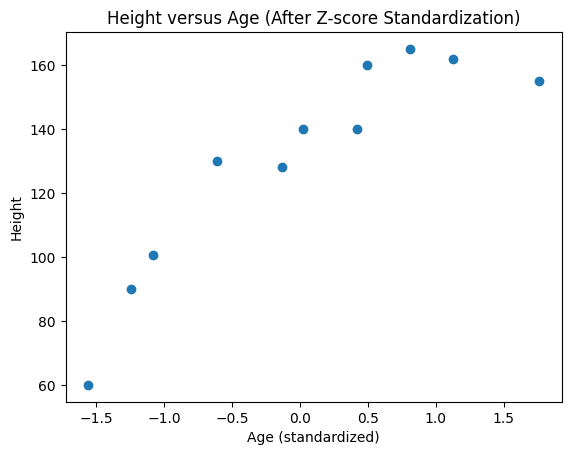

Y-intercept (theta_0) is: 130.04545454545453


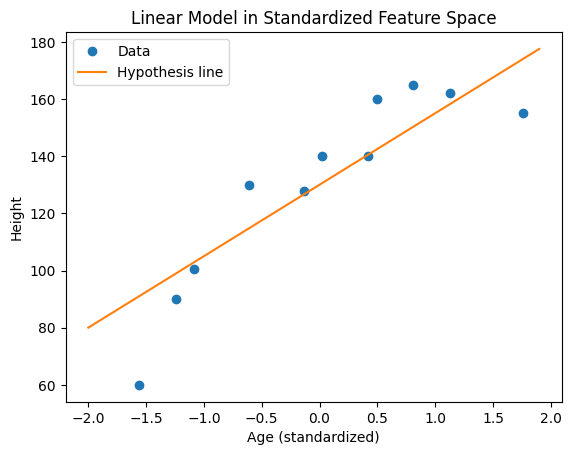

In [12]:
# -------------------------------------------------------------
# Z-score Normalization of the input feature (Age)
# -------------------------------------------------------------
# This rescales X so that it has mean 0 and standard deviation 1.
# After normalization, values typically lie in the range [-2, 2].

X_new = (X - np.mean(X)) / np.std(X)

# -------------------------------------------------------------
# Plot the normalized data
# -------------------------------------------------------------
plt.plot(X_new, Y, "o")
plt.title("Height versus Age (After Z-score Standardization)")
plt.xlabel("Age (standardized)")
plt.ylabel("Height")
plt.show()

# -------------------------------------------------------------
# Setting theta_0 (intercept)
# -------------------------------------------------------------
# When the input feature has mean 0, the optimal intercept theta_0
# is simply the mean of the target variable Y.

t0 = np.mean(Y)
print("Y-intercept (theta_0) is:", t0)

# -------------------------------------------------------------
# Generate x values in standardized feature space
# -------------------------------------------------------------
# Since X is standardized, reasonable values lie between -2 and 2.

x2 = np.arange(-2, 2, 0.1)

# -------------------------------------------------------------
# Plot a guessed regression line
# -------------------------------------------------------------
# We fix theta_0 using the mean of Y and guess a value for theta_1.
# This line is for visualization only, not the result of training.

t1_guess = 25
y2 = t0 + t1_guess * x2

plt.plot(X_new, Y, "o", label="Data")
plt.plot(x2, y2, label="Hypothesis line")
plt.xlabel("Age (standardized)")
plt.ylabel("Height")
plt.title("Linear Model in Standardized Feature Space")
plt.legend()
plt.show()


We can now re-structure the above to use Gradient Descret to search only for $\theta_{1}$.  

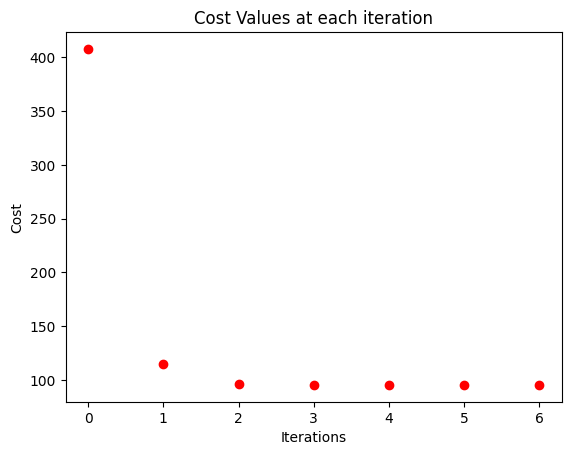

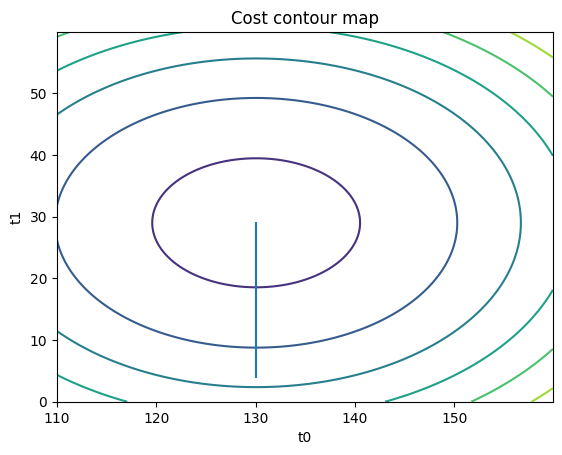

Learned parameters:
theta_0 (fixed) = 130.04545454545453
theta_1 (learned) = 28.99747992534312


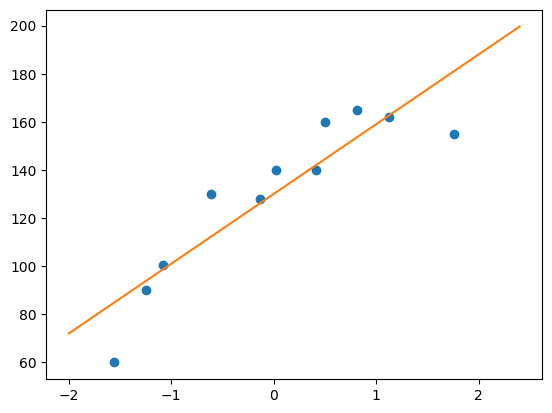

In [13]:
def gd1(t0_in, t1_in, min_delta_in, a_in, X_in, Y_in, hyp_in):
    """
    Gradient Descent to optimize ONLY theta_1,
    assuming theta_0 is fixed.

    Inputs:
    t0_in        -- fixed value for theta_0
    t1_in        -- initial guess for theta_1
    min_delta_in -- stopping threshold
    a_in         -- learning rate
    X_in         -- input feature (normalized)
    Y_in         -- target values
    hyp_in       -- hypothesis function
    """

    m = len(X_in)
    c = []      # cost history
    t1s = []    # theta_1 history

    t1 = t1_in
    t1s.append(t1)

    # Python does not have a do-while loop,
    # so we use an infinite loop with a break condition.
    while True:

        # Compute and store the cost using fixed theta_0
        c.append(J(t0_in, t1, X_in, Y_in, hyp_in))

        temp1 = t1

        # Compute gradient with respect to theta_1
        s = 0
        for i in range(m):
            s += (hyp_in(t0_in, temp1, X_in[i]) - Y_in[i]) * X_in[i]

        # Gradient descent update for theta_1
        t1 = temp1 - a_in * (1/m) * s

        t1s.append(t1)

        # Stop if the update is sufficiently small
        if abs(temp1 - t1) < min_delta_in:
            break

    return t1s, c

md = 0.01
a2 = 0.75
t1s, c = gd1(t0,4,md,a2,X_new,Y,hyp)

plt.plot(c, 'ro')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title("Cost Values at each iteration")
plt.show()

plt.figure()

theta0_range = np.arange(110,160,0.1)
theta1_range = np.arange(0,60,0.1)
theta0s_new, theta1s_new = np.meshgrid(theta0_range, theta1_range)

costs_new = J(theta0s_new,theta1s_new,X_new,Y,hyp)

CS = plt.contour(theta0s_new, theta1s_new, costs_new)
plt.plot([t0]*len(t1s),t1s)
plt.title("Cost contour map")
plt.xlabel('t0')
plt.ylabel('t1')
plt.show()

x2 = np.arange(-2,2.5,0.1)
t1 = t1s[-1]
print(f"Learned parameters:")
print(f"theta_0 (fixed) = {t0}")
print(f"theta_1 (learned) = {t1}")
y2 = t0 + t1*x2
plt.plot(X_new,Y, "o")
plt.plot(x2,y2)
plt.show()

### Using the Model with New Data

Note that we **do not convert the learned parameters** $\theta_0$ and $\theta_1$ back into the original feature space.  
Instead, **any new test input must be transformed using the same normalization** that was applied to the training data.

This is critical because the model was trained **in the normalized feature space**, and the parameters are only valid in that space.

---

### Predicting a New Example

Suppose we are given a new input value representing an individual’s age:

$$
x_i = 20
$$

Before making a prediction, we must **apply the same Z-score normalization** used during training:

$$
x_i' = \frac{x_i - \mu_X}{\sigma_X}
$$

where:  
- $\mu_X$ is the mean of the training feature values  
- $\sigma_X$ is the standard deviation of the training feature values

---

### Making the Prediction

Once the input has been normalized, we apply the learned hypothesis function:

$$
\hat{y} = \theta_0 + \theta_1 x_i
$$

This gives the predicted height for an individual aged 20.

---

### Key Point

**Always normalize test data using the training mean and standard deviation.**  
Never re-normalize using statistics computed from the test data itself.
The reason is:

- Training defines a coordinate system  
- Normalization fixes that coordinate system  
- Model expects inputs normalized using the training statistics. If you use test stats, the inputs are shifted and rescaled differently, breaking the alignment the model was trained on.

Therefore, all future inputs must be expressed in the same coordinates.  



In [14]:
# New input value: age of an individual
x1 = 20

# Transform the input feature into the normalized feature space
x1_prime = (x1 - np.mean(X)) / np.std(X)

# Calculate the predicted height using the learned parameters
y1 = t0 + t1 * x1_prime

# Display the predicted height
print("Predicted height for age", x1, "is:", y1)


Predicted height for age 20 is: 171.93264254506227


## Multivariate Regression

So far our explanations and examples have centered around a simple case with only **one feature**.  
Linear Regression straightforwardly scales up to deal with **multiple features**.

---

### Multivariate Hypothesis Function

When we have multiple features, the hypothesis function can be extended as:

$$
h_{\theta}(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n
$$

where we have \(n\) different features.

We can simplify this notation using a summation:

$$
h_{\theta}(x) = \theta_0 + \sum_{i=1}^{n} \theta_i x_i
$$

---

### Handling the Bias Term ($\theta_0\$)

Currently, $\theta_0$ is handled separately from the other features.  
We can make it uniform by noting:

$$
\theta \cdot 1 = \theta
$$

Thus, the hypothesis can be rewritten as:

$$
h_{\theta}(x) = \theta_0 \cdot 1 + \sum_{i=1}^{n} \theta_i x_i
$$

Or, if we introduce a **dummy variable** $x_0 = 1\$:

$$
h_{\theta}(x) = \theta_0 x_0 + \sum_{i=1}^{n} \theta_i x_i
$$

Which can be concisely written as:

$$
h_{\theta}(x) = \sum_{i=0}^{n} \theta_i x_i
$$

where $x_0 = 1$ and the other $x_i$ are the actual features.  
Note: This is just the **dot product** (scalar product) of two vectors.

---

### Vectorized Multivariate Hypothesis Function

This vectorized notation is particularly useful for computation:

$$
h_{\theta}(x) = \theta^T x
$$

This works because our hypothesis is a summation of products of input features and parameters.

---

### Example: Single Data Point

For illustration, suppose we have:

- Two features per example: $x_1, x_2$
- Bias term $x_0 = 1$
- Learned parameters: $$\theta = [\theta_0, \theta_1, \theta_2]$$

Then, for a single data point:

$$
x = [x_0, x_1, x_2] \quad \text{and} \quad h_\theta(x) = \theta^T x
$$


In [15]:
# let's define our two parameters into a single vector
theta = np.array([t0,t1])
# now lets define our input date. Remember that we need to create a dummy value for x_{0}
# which we set equal 1.
# This allows us to handle the bias term uniformly as a weight multiplied by a feature.

# x1_prime is the actual input feature value.
x = np.array([1,x1_prime])
# now multiply the matrices together
result = np.matmul(theta.T,x)
print(result)

171.93264254506227


#### Parallelism through Vectorization
This vectorized approach is useful not only because of the simple notation, but it allows us to easily write out and make calculations for multiple sets of parameters in a single computational step. To illustrate this, we can extend the case above to handle multiple data points by substituting the matrix multiplication operator for the simple inner product operator.

In [16]:
# define the raw input data pints (different values for age)
ages = np.array([12.5,17.5,20,21,25])
# normalize these based on previously established paramters
ages = (ages-np.mean(X))/np.std(X)
# construct the data matrix x that includes dummy values for x_{0} as well as the real
# age values for x_{1}
x = np.matrix([[1,1,1,1,1],ages])
# now we can matrix multiply
# because x contains all values, we compute predictions in paralel instead of looping
results = np.matmul(theta.T,x)
print(results)

[[137.54763747 160.47097419 171.93264255 176.51730989 194.85597926]]


Furthermore we can extend the approach to allow us to calculate the resultant values for each data point for multiple different sets of hypotheses. This can be useful if we ever want to test multiple sets of parameters in parallel.

In [17]:
# construct the matrix of parameters where each row is a single set of parameters i.e., theta
# first one is learned, and we are also trying out [120,30] as model params over the input matrix
thetas = np.matrix([[t0,t1],[120,30]])
print(thetas)

results = np.matmul(thetas,x)
print(results)

[[130.04545455  28.99747993]
 [120.          30.        ]]
[[137.54763747 160.47097419 171.93264255 176.51730989 194.85597926]
 [127.76155336 151.47741085 163.3353396  168.07851109 187.05119709]]


### Multivariate Cost Function
By introducing $x_{0}=1$ we can straightforwardly rework our cost function to treat all parameters equally. The generalized form of our Cost Function becomes:

\begin{equation}
J(\theta) = \frac{1}{2m}     \sum_{i=0}^{m} ( h_{\theta}(x^{(i)}) - y^{(i)})^{2}
\end{equation}

or in code:

In [18]:
def J(theta,x,y):
    sse = 0
    m = len(x)
    for i in range(0,m):
        h = np.matmul(theta,x[i,:].T)
        error = h - y[i]
        sqerror = error**2
        sse+= sqerror
    return sse / (2*m)

While the general form of our gradient descent algorithm becomes:

Repeat Until Convergence {

  perform simultaneously {

 \begin{equation}
\theta_{j} = \theta_{j} - \alpha \frac{1}{m} \sum_{i=0}^{m} (h_{\theta}(x^{(i)}) - y^{(i)}).x_{j}^{i}
\end{equation}
  }
}

We can rewrite our gradient descent implementation to work with this generic design. The inputs to our algorithm are now:
 * $\theta_{in}$ - a vector of initial parameterizations
 * $min_delta$ - the minimum change in delta permissible before gradient descent stops
 * $a_{in}$ - the learning rate
 * $X_in$ - a matrix of input feature vectors
 * $Y_in$ - a vector of target variables of length m

Our function returns
 * $\theta$ values - a matrix of vectors where each vector is a set of parameters at a particular epoch

Note that in this simplified form we have:
 * removed the input parameter hyp_in since we now assume the hypothesis function is always of the form $\theta^{T}x$
 * stopped calculating the cost for each iteration. Instead this can be calculated afterward for visualization if needed

In [19]:
def gd(theta_in,min_delta_in,a_in,X_in,Y_in):
    m = len(Y_in) # number of training examples
    _ , n = np.shape(X_in) # number of features

    theta = theta_in
    thetas = np.array(theta_in,ndmin=2)

    while True:
        temp = np.copy(theta)
        for j in range(0,n):
            # making calculations for jth parameter
            s = 0
            for i in range(0,m):
                s+=  (np.matmul(temp.T,np.ravel(X_in[i,:])) - Y_in[i])  * X_in[i,j]
            theta[j] = temp[j] - a_in * (1/m) * s
        thetas = np.vstack((thetas,theta))

        progressing = False
        for j in range(0,n):
            if(abs(temp[j] - theta[j]) > min_delta_in):
                progressing = progressing | True
        if not progressing: break
    return thetas

To demonstrate this new implementation we can firstly test it against our original single feature height and age example as follows:

In [20]:
# define initial values for theta
theta = np.array([t0,10])
# set min_delta and the learning rate (a)
md = 0.01
a = 0.75
# define the new matrix X based around our normalized vector for X previously obtained
x_0 = [1]*len(X_new)
X = np.matrix([x_0,X_new]).T

thetas = gd(theta,md,a,X,Y)
print("Theta0 and Theta1")
print(thetas[-1:])

Theta0 and Theta1
[[130.04545455  28.99784614]]


We note that since we initialized $\theta_{0}$ to the calculated value obtained when we normalized our input feature, that the value of $\theta_{0}$ never changed. We also note that the final value for $\theta_{1}$ is almost identical to the calculation we made for it earlier.

### A Simple Multivariate Example

We can try a proper, though simple, multivariate case by defining a new multivariate data set. For this example we will look at the relationship between a target variable Growth and two input features Average Temperature and Average Rainfall.

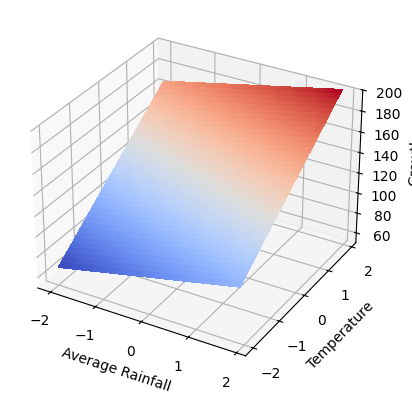

In [21]:
# define our new data
Y = np.array([100,110,120,120,148,130,170,140,195])
X = np.array([[22,107],[28,110],[35,100],[21,201],[29,210],[33,201],[22,330],[25,330],[33,340]])

# Redefine our standardization operation to work over 2D arrays
def standardize(x):
    col_means = np.mean(x,axis=0)
    col_std = np.std(x,axis=0)
    return (x - col_means) / col_std , col_means, col_std

# standardize our input features
X, means, stds = standardize(X)

# define initial values for theta
rows, cols = X.shape
theta = np.ones(1+cols)*1
theta[0] = np.mean(Y) # remember - we directly calculate t0

# set min_delta and learning rate (a)
md = 0.01
a = 0.05

# define the new matrix X based around our standardized vector for X previously obtained
x_0 = np.array([1]*rows)
X = np.hstack((x_0[:, np.newaxis],X))

# Run gradient descent
thetas = gd(theta,md,a,X,Y)

# plot a surface based on the returned function parameters

# initialize values for features x1 and x2
x_range = np.arange(-2,2,0.1)

x1s, x2s = np.meshgrid(x_range, x_range) # remember - plt.surface likes this meshgrid output
mesh_rows, mesh_cols = x1s.shape

# construct 1D arrays for x1, x2 and x0
x1 = np.ravel(x1s)
x2 = np.ravel(x2s)
x0 = np.array([1]*len(x2))

# merge 1D arrays into a single x array for calculations \n",
x = np.matrix([x0,x1,x2])

# perform calculations \n",
z = np.matmul(thetas[-1,:],x)

# reshape result to have the same organization as result of meshgrid \n",
zs = np.reshape(z,(mesh_rows,mesh_cols))

# plot the surface along with our training data points
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(x1s, x2s, zs, rstride=1, cstride=1, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)
surf = ax.scatter(X[:,2], X[:,1], Y, c='r', marker='o')
ax.set_xlabel('Average Rainfall')
ax.set_ylabel('Temperature')
ax.set_zlabel('Growth')
ax.set_zlim(50, 200)
plt.show()

## Linear Regression with Non-Linear Inputs (Polynomial Regression)

In our previous vectorized calculations, we assumed that our hypothesis function is always of the form:

\begin{equation}
h_\theta(x) = \sum_{i=0}^{n} \theta_i x_i
\end{equation}

Here, the model is **linear in the parameters** \(\theta_i\).

However, in the Age versus Height example, we observed that a more complex relationship between age and height could be better approximated by a polynomial:

\begin{equation}
Y = 50 + 15X - 0.68 X^2 + 0.011 X^3
\end{equation}

Notice that while this function is **non-linear in the input** \(X\), it is still **linear in the parameters** \(\theta_0, \theta_1, \theta_2, \theta_3\).  

We can handle such cases in linear regression by **pre-computing additional features**, such as \(X^2\) and \(X^3\), and including them in our input matrix. This effectively maps the original feature \(X\) into a higher-dimensional feature space, allowing the linear model to capture non-linear relationships in the original input.  

Using this approach, we can redefine our Age and Height example to work with the same **vectorized gradient descent algorithm**, without any changes to the underlying optimization procedure. This is sometimes referred to as **polynomial regression**, and it is a simple example of how **linear models can handle non-linear patterns by transforming the input space**.

This idea also generalizes to neural networks: instead of manually defining polynomial features, neural networks **learn non-linear transformations of the input features automatically** before applying a linear combination at the output layer.
## Linear Regression with Non-Linear Inputs (Polynomial Regression)

In our previous vectorized calculations, we assumed that our hypothesis function is always of the form:

\begin{equation}
h_\theta(x) = \sum_{i=0}^{n} \theta_i x_i
\end{equation}

Here, the model is linear in the parameters $\theta_i\$.

However, in the Age versus Height example, we observed that a more complex relationship between age and height could be better approximated by a polynomial:

\begin{equation}
Y = 50 + 15X - 0.68 X^2 + 0.011 X^3
\end{equation}

Notice that while this function is non-linear in the input $X$, it is still linear in the parameters $\theta_0, \theta_1, \theta_2, \theta_3$.  

We can handle such cases in linear regression by pre-computing additional features, such as $X^2$ and $X^3$, and including them in our input matrix. This effectively maps the original feature $X$ into a higher-dimensional feature space, allowing the linear model to capture non-linear relationships in the original input.  

Using this approach, we can redefine our Age and Height example to work with the same vectorized gradient descent algorithm, without any changes to the underlying optimization procedure. This is sometimes referred to as polynomial regression, and it is a simple example of how linear models can handle non-linear patterns by transforming the input space.

As you will see in the following weeks, this idea also generalizes to neural networks: instead of manually defining polynomial features, **neural networks learn non-linear transformations of the input features automatically** before applying a linear combination at the output layer.

**Polynomial Features in Linear Regression:**

To model non-linear relationships, we can **transform the original features** into higher-degree terms. For example, if the original feature is $X$, we can create new features:

\begin{equation}
x_0 = 1, \quad x_1 = X, \quad x_2 = X^2, \quad x_3 = X^3
\end{equation}

The linear regression hypothesis applied to these features becomes:

\begin{equation}
h_\theta(x) = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_3
\end{equation}

Even though the relationship between $X$ and $Y$ may be non-linear, the model is still **linear in the parameters** $theta$, so standard gradient descent or normal equation methods can be used.  

Every time we fit the model, we need to **apply the same feature transformations** to the input data. This approach is called **polynomial regression**.


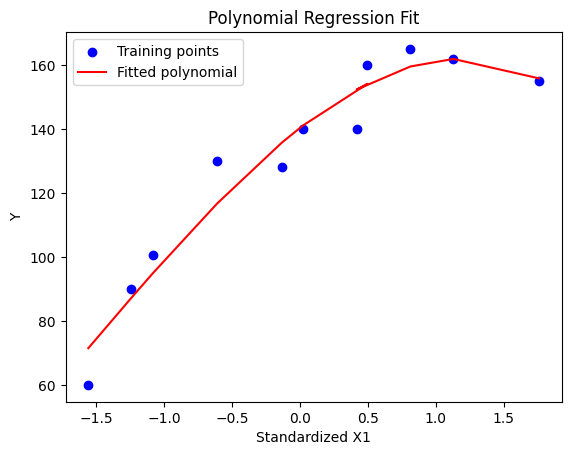

Parameters obtained for this normalized data:
[130.04545455  49.99775512   1.83563491 -25.67787883]


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Example target variable (Y) and feature (X1)
Y = np.array([60, 90, 100.5, 130, 128, 140, 160, 140, 165, 162, 155])
x1 = np.array([1, 3, 4, 7, 10, 11, 14, 13.5, 16, 18, 22])

# -----------------------------
# Step 1: Create polynomial features
# -----------------------------
# x2 = X^2, x3 = X^3
x2 = x1**2
x3 = x1**3

# Stack features into a matrix (rows = samples, cols = features)
X = np.vstack((x1, x2, x3)).T  # shape: (11, 3)

# -----------------------------
# Step 2: Standardize features
# -----------------------------
# Standardization improves gradient descent convergence
# Assume `standardize()` returns standardized X, means, stds
X, means, stds = standardize(X)

# -----------------------------
# Step 3: Initialize parameters (theta)
# -----------------------------
rows, cols = X.shape
theta = np.ones(cols + 1)  # extra 1 for intercept term
theta[0] = np.mean(Y)       # initial t0 can be mean of Y

# -----------------------------
# Step 4: Set gradient descent hyperparameters
# -----------------------------
md = 0.01  # min_delta for convergence
a = 0.05   # learning rate

# -----------------------------
# Step 5: Add intercept column to X
# -----------------------------
x0 = np.ones((rows, 1))  # column of 1s
X = np.hstack((x0, X))   # X shape now (rows, features+1)

# -----------------------------
# Step 6: Run gradient descent
# -----------------------------
# gd() is assumed to return a matrix of theta values at each epoch
thetas = gd(theta, md, a, X, Y)

# -----------------------------
# Step 7: Prepare data for visualization
# -----------------------------
x1s = X[:, 1]  # original standardized x1
x2s = X[:, 2]
x3s = X[:, 3]
x0s = np.ones(len(x1s))

# Combine into matrix for prediction
xs = np.vstack((x0s, x1s, x2s, x3s)).T

# -----------------------------
# Step 8: Compute predicted values using the final optimized theta
# -----------------------------
ys = np.matmul(thetas[-1, :], xs.T)  # final predictions

# -----------------------------
# Step 9: Plot training data and fitted polynomial curve
# -----------------------------
plt.scatter(X[:, 1], Y, color='blue', label='Training points')  # original X1 vs Y
plt.plot(x1s, ys, color='red', label='Fitted polynomial')       # fitted curve
plt.xlabel('Standardized X1')
plt.ylabel('Y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()

# -----------------------------
# Step 10: Print optimized parameters
# -----------------------------
print('Parameters obtained for this normalized data:')
print(thetas[-1, :])


# Assignments and Questions

These exercises are designed to help you experiment with—and and also “break”—the examples we’ve covered so far:

 - Create your own examples using maximum daily temperature versus day of the year.

- Run your data through modelling and visualisation.

- Make predictions and compare them with what you would expect based on your data points.

Once you’ve done that, try creating a multivariate example, for instance, Squirrel Weight as a function of day of year and age. If that doesn’t appeal to you, pick another multivariate regression topic that you find interesting and that you can implement quickly.

## Notes
- You can run notebooks on Colab or any notebook server of your choice.  
- Setting up a local Python environment using `venv` and `pip` is recommended, but not required. This allows you to install packages like TensorFlow and experiment offline.
